# Synthetic Cohort Generation for AI DR Screening Evaluation

This notebook generates a simulated patient cohort representing the diabetic
retinal screening population in Aotearoa New Zealand. The cohort includes
demographic characteristics (ethnicity, age, sex, area deprivation) and true
diabetic retinopathy (DR) status, drawn from published NZ clinical and
population data.

We then simulate AI screening predictions for three tool profiles derived from
published clinical trial results, under two equity scenarios (equal and
differential performance by subgroup).

**Key references:**
- Simmons et al. (2007) *Diabet Med* — NZ DR prevalence by ethnicity
- Loring et al. (2022) *NZ Med J* — NZDep distribution by ethnicity
- Abramoff et al. (2018) *NPJ Digit Med* — IDx-DR pivotal trial
- Vaghefi et al. (2023) *Eye* — THEIA NZ prospective trial

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cohort import load_parameters, generate_cohort, simulate_predictions
from src.visualisation import set_style, ETHNICITY_LABELS

set_style()
%matplotlib inline

## 1. Load Simulation Parameters

All numerical parameters are stored in `config/parameters.yaml` with inline
citations to their published sources. This keeps the simulation transparent
and auditable.

In [2]:
params = load_parameters("../config/parameters.yaml")

# Quick check: ethnicity proportions should sum to 1
eth_props = params["demographics"]["ethnicity_proportions"]
print("Ethnicity proportions:", eth_props)
print(f"Sum: {sum(eth_props.values()):.2f}")

Ethnicity proportions: {'nz_european': 0.48, 'maori': 0.16, 'pacific': 0.12, 'asian': 0.19, 'other': 0.05}
Sum: 1.00


## 2. Generate Cohort

Generating a cohort of 10,000 simulated patients. Each patient is assigned:
- **Ethnicity** — sampled from NZ diabetic population proportions
- **Age** — truncated normal distribution (mean 62, SD 14)
- **Sex** — 46% female (NZ Virtual Diabetes Register)
- **NZDep quintile** — conditional on ethnicity (Loring et al., 2022)
- **DR status** — prevalence conditional on ethnicity (Simmons et al., 2007)

In [3]:
cohort = generate_cohort(params)
print(f"Cohort size: {len(cohort):,}")
print(f"Referable DR cases: {cohort['has_referable_dr'].sum()} "
      f"({cohort['has_referable_dr'].mean():.1%})")
print(f"Any DR cases: {cohort['has_any_dr'].sum()} "
      f"({cohort['has_any_dr'].mean():.1%})")
cohort.head(10)

Cohort size: 10,000
Referable DR cases: 709 (7.1%)
Any DR cases: 2729 (27.3%)


,patient_id,ethnicity,sex,age,nzdep_quintile,has_any_dr,has_referable_dr
0,1,asian,Male,36,3,False,False
1,2,nz_european,Male,56,5,False,False
2,3,asian,Female,37,5,False,False
3,4,pacific,Female,90,5,False,False
4,5,nz_european,Female,64,4,False,False
5,6,other,Female,63,2,False,False
6,7,asian,Female,65,3,False,False
7,8,asian,Male,70,4,True,False
8,9,nz_european,Female,75,1,True,False
9,10,nz_european,Female,40,5,False,False


## 3. Demographics Overview

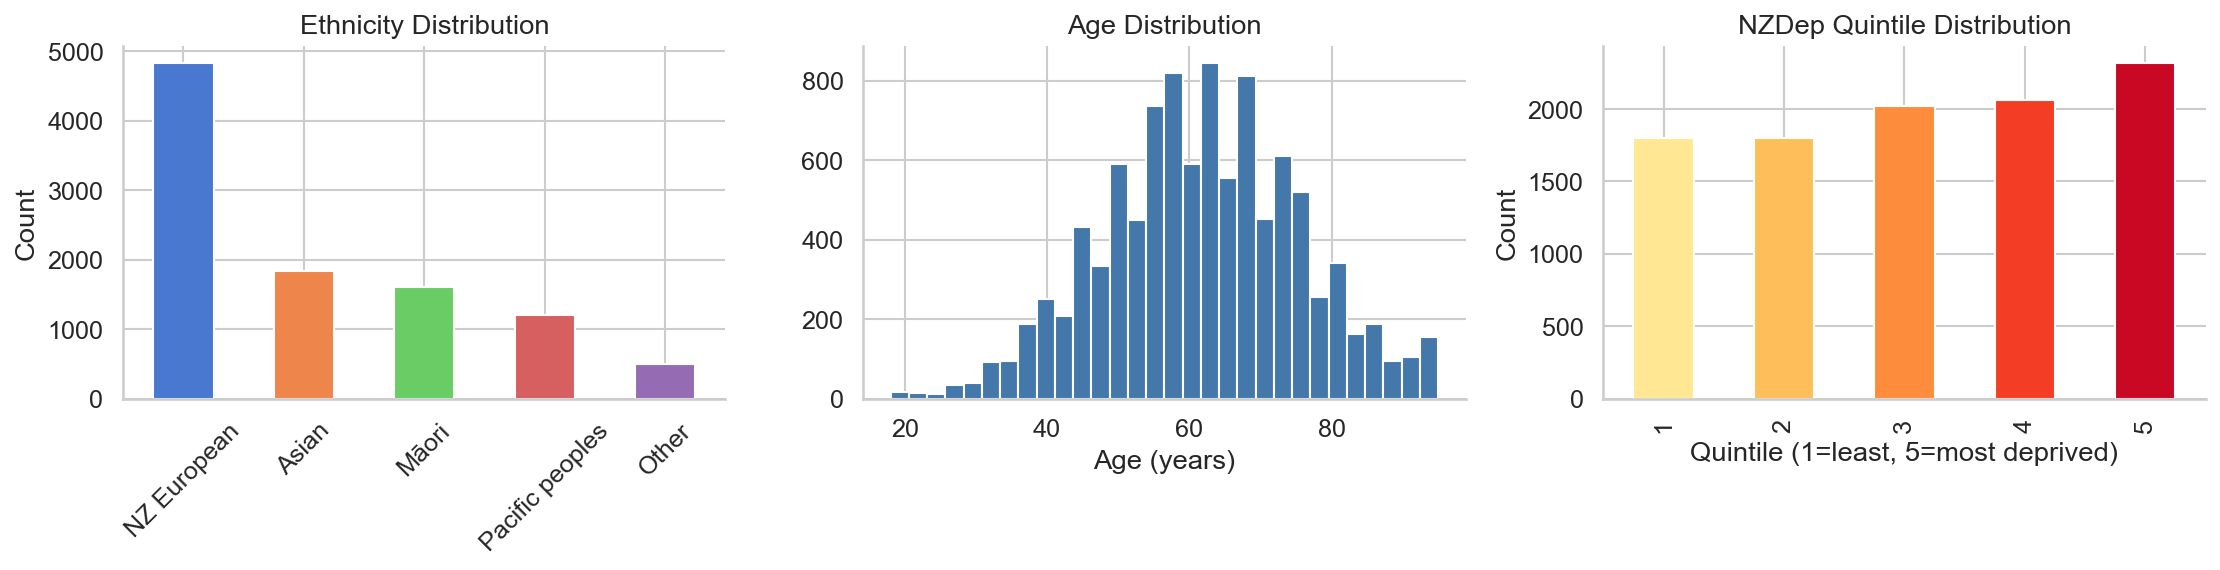

In [4]:
# Ethnicity distribution
eth_counts = cohort["ethnicity"].value_counts()
eth_counts.index = [ETHNICITY_LABELS.get(e, e) for e in eth_counts.index]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ethnicity
eth_counts.plot.bar(ax=axes[0], color=sns.color_palette("muted", len(eth_counts)))
axes[0].set_title("Ethnicity Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Age
cohort["age"].hist(ax=axes[1], bins=30, edgecolor="white", color="#4477AA")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age (years)")

# NZDep
cohort["nzdep_quintile"].value_counts().sort_index().plot.bar(
    ax=axes[2], color=sns.color_palette("YlOrRd", 5)
)
axes[2].set_title("NZDep Quintile Distribution")
axes[2].set_xlabel("Quintile (1=least, 5=most deprived)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/figures/cohort_demographics.png")
plt.show()

In [5]:
# NZDep distribution by ethnicity — cross-tabulation
nzdep_eth = pd.crosstab(
    cohort["ethnicity"].map(ETHNICITY_LABELS),
    cohort["nzdep_quintile"],
    normalize="index",
)
nzdep_eth.columns = [f"Q{c}" for c in nzdep_eth.columns]

print("NZDep quintile distribution by ethnicity (row proportions):")
print(nzdep_eth.round(3).to_string())

NZDep quintile distribution by ethnicity (row proportions):
                    Q1     Q2     Q3     Q4     Q5
ethnicity                                         
Asian            0.152  0.185  0.244  0.229  0.189
Māori            0.079  0.104  0.142  0.258  0.418
NZ European      0.258  0.232  0.225  0.170  0.114
Other            0.188  0.192  0.230  0.176  0.216
Pacific peoples  0.040  0.058  0.116  0.261  0.526


In [6]:
# DR prevalence by ethnicity
dr_by_eth = cohort.groupby("ethnicity").agg(
    n=("patient_id", "count"),
    any_dr=("has_any_dr", "mean"),
    referable_dr=("has_referable_dr", "mean"),
).reset_index()
dr_by_eth["ethnicity_label"] = dr_by_eth["ethnicity"].map(ETHNICITY_LABELS)
print("DR prevalence by ethnicity:")
print(dr_by_eth[["ethnicity_label", "n", "any_dr", "referable_dr"]].to_string(index=False))

DR prevalence by ethnicity:
ethnicity_label    n   any_dr  referable_dr
          Asian 1844 0.292842      0.070499
          Māori 1611 0.301676      0.135940
    NZ European 4833 0.247879      0.035796
          Other  501 0.245509      0.057884
Pacific peoples 1211 0.315442      0.130471


## 4. Simulate AI Predictions

We simulate predictions for three AI tool profiles under two scenarios:

1. **Equal performance** — the AI performs identically across all subgroups
2. **Differential performance** — performance varies modestly by ethnicity and deprivation, based on evidence of AI underdiagnosis bias in underserved populations (Seyyed-Kalantari et al., 2021)

In [7]:
# Generate predictions for all tool x scenario combinations
results = {}
for tool_key in ["tool_a", "tool_b", "tool_c"]:
    for scenario in ["equal", "differential"]:
        label = f"{tool_key}_{scenario}"
        df = simulate_predictions(cohort, params, tool_key=tool_key, scenario=scenario)
        results[label] = df

        tp = ((df["ai_prediction"]) & (df["has_referable_dr"])).sum()
        fn = ((~df["ai_prediction"]) & (df["has_referable_dr"])).sum()
        fp = ((df["ai_prediction"]) & (~df["has_referable_dr"])).sum()
        tn = ((~df["ai_prediction"]) & (~df["has_referable_dr"])).sum()

        print(f"{label}: sens={tp/(tp+fn):.3f}, spec={tn/(tn+fp):.3f}, "
              f"TP={tp}, FN={fn}, FP={fp}, TN={tn}")

tool_a_equal: sens=0.931, spec=0.934, TP=660, FN=49, FP=612, TN=8679
tool_a_differential: sens=0.891, spec=0.900, TP=632, FN=77, FP=928, TN=8363
tool_b_equal: sens=0.908, spec=0.893, TP=644, FN=65, FP=994, TN=8297
tool_b_differential: sens=0.828, spec=0.864, TP=587, FN=122, FP=1264, TN=8027
tool_c_equal: sens=0.982, spec=0.983, TP=696, FN=13, FP=156, TN=9135
tool_c_differential: sens=0.946, spec=0.950, TP=671, FN=38, FP=461, TN=8830


## 5. Save Simulated Data

Save the generated datasets for use in the performance evaluation and equity
analysis notebooks.

In [8]:
# Save base cohort
cohort.to_csv("../data/cohort.csv", index=False)

# Save each simulation result
for label, df in results.items():
    df.to_csv(f"../data/predictions_{label}.csv", index=False)

print(f"Saved cohort ({len(cohort)} patients) and {len(results)} prediction sets.")
print("Files written to ../data/")

Saved cohort (10000 patients) and 6 prediction sets.
Files written to ../data/
